## Normalizasyon nedir?
- Veri setindeki değişkenlerin farklı ölçeklerde olması model performansını olumsuz etkiler.
- Normalizasyon, verileri ortak bir ölçeğe getirerek daha dengeli bir öğrenme sağlar.
- Amaç: Tüm özelliklerim modele eşit katkı yapabilmesini sağlamak
- Örnek: Yaş (0-100) ve Gelir (0-100.000) -> ölçek farkı modeli yanılabilir

## Neden Normalizasyon Gerekir?
- Değişkenlerin ölçü birimleri farklı olabilir (TL,yaş,mesafe,sıcaklık).
- Ölçek farkı, modelin bazı değişkenleri "daha önemli" sanmasına yol açar.
- Normalizasyon, bu farklı giderir ve veriyi karşılaştırabilir hale getirir.
- Modelin öğrenme sürecinde adil ve dengeli bir yapı sağlar.

## Normalizasyonun Temel Mantığı
- Her sütundaki değerler belli bir aralığa dönüştürülür.
- En küçük değer 0, en büyük değer 1 olacak şekilde ölçeklenir.
- Sıralama korunur, sadece ölçek küçülür.


## Normalizasyon Türleri

### Min-Max Normalizayon
- Değerleri [0,1] aralığına çeker.
- Basit, hızlı ve sezgiseldir.
- Aykırı değerlere duyarlıdır.
- (x - min) / (max - min)

### Z-Score (Standardizasyon)
- Ortalama = 0, Standart sapma = 1
- Negatif ve pozitif değerler olabilir.
- Aykırı değerlerden min-max kadar etkilenmez.

### Robust Scaling
- Medyan ve çeyrekler arası fark (IQR) kullanılır.
- Uç değerlere karşı dayanıklıdır.
- Dağılımın merkezine odaklanır.


### Log Dönüşümü
- Çarpık dağılımı daha simetrik hale getirir.
- Büyük değerleri küçültür, küçük farkları belirginleştirir.
- Negatif değerlere uygulanmaz.

# Normalizasyon
- Manuel Normalizasyon
- Kütüphane kullanarak Normalizasyon
- Normalizasyon yapmazsak ne olur?
- Durum çalışması: gerçek veri seti ile normalizasyon çalışması


## Manuel Normalizasyon
Bu bölümde:
- Küçük bir örnek veri seti oluşturalım
- Dört farklı normalizasyon yöntemini formüller ile kendimiz uygulayalım:
  - Min-Max normalizasyon
  - Z-Score standardization
  - Robust Scaling
  - Log Dönüşüm
- Her yöntemin çıktısını değerlendir

In [ ]:
# gerekli kütüphaneleri içeri aktar
import numpy as np
import pandas as pd

In [ ]:
#veri seti oluşturma
#öğrencilerin boyu, kilosu, gelir durumu
data = {
    "boy": [150,160,170,180,190],
    "kilo": [45,60,70,80,120],
    "gelir": [20000,25000,27000,30000,150000] #son değer outlier
}
df = pd.DataFrame(data)
df

,boy,kilo,gelir
0,150,45,20000
1,160,60,25000
2,170,70,27000
3,180,80,30000
4,190,120,150000


In [ ]:
# manuel normalizasyon
# min max normalizasyon
# formül: (X - min) / (max - min)
df_minmax = (df - df.min()) / (df.max() - df.min())
df_minmax

,boy,kilo,gelir
0,0.00,0.000000,0.000000
1,0.25,0.200000,0.038462
2,0.50,0.333333,0.053846
3,0.75,0.466667,0.076923
4,1.00,1.000000,1.000000


In [ ]:
# z-score (standardizasyon)
# formül = (X - mean) / std
df_zscore = (df - df.mean()) / df.std()
df_zscore

,boy,kilo,gelir
0,-1.264911,-1.060660,-0.544833
1,-0.632456,-0.530330,-0.455222
2,0.000000,-0.176777,-0.419378
3,0.632456,0.176777,-0.365611
4,1.264911,1.590990,1.785044


In [ ]:
# robust scaling
# formül = (X - median) / IQR
# IQR = 3.çeyrek - 1.çeyrek
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
df_robust = (df - df.median()) / IQR
df_robust

,boy,kilo,gelir
0,-1.0,-1.25,-1.4
1,-0.5,-0.50,-0.4
2,0.0,0.00,0.0
3,0.5,0.50,0.6
4,1.0,2.50,24.6


In [ ]:
# log dönüşümü
# formül = log(X + 1)
df_log = np.log(df + 1)
df_log

,boy,kilo,gelir
0,5.017280,3.828641,9.903538
1,5.081404,4.110874,10.126671
2,5.141664,4.262680,10.203629
3,5.198497,4.394449,10.308986
4,5.252273,4.795791,11.918397


In [ ]:
summary = pd.DataFrame({
    "orijinal_ortalama": df.mean(),
    "minmax_ortalama": df_minmax.mean(),
    "zscore_ortalama": df_zscore.mean(),
    "robust_ortalama": df_robust.mean(),
    "log_ortalama": df_log.mean()
}).round(3)
summary

,orijinal_ortalama,minmax_ortalama,zscore_ortalama,robust_ortalama,log_ortalama
boy,170.0,0.500,0.0,0.00,5.138
kilo,75.0,0.400,0.0,0.25,4.278
gelir,50400.0,0.234,-0.0,4.68,10.492


## Python Sklearn ile Normalizasyon
Bu bölümde:
- Yeni bir veri seti oluşturalım (mağaza satışları)
- 4 farklı ölçeklendirme yöntemini uygula: min-max, z-score,robust ve log dönüşümü
- Sonuçları karşılaştıralım


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

In [ ]:
# örnek veri seti oluştur
# farklı mağazalara ait satış ve müşteri bilgileri
data = {
    "satis_tutari": [2000,5000,7000,10000,120000],
    "musteri_sayisi": [50,65,80,100,300],
    "urun_cesidi": [10,20,25,30,60],
    "iade_orani": [0.02,0.03,0.05,0.04,0.5]
}
df = pd.DataFrame(data)
df

,satis_tutari,musteri_sayisi,urun_cesidi,iade_orani
0,2000,50,10,0.02
1,5000,65,20,0.03
2,7000,80,25,0.05
3,10000,100,30,0.04
4,120000,300,60,0.50


In [ ]:
# min max normalizasyon
# formül: (X- Xmin) / (Xmax- Xmin)
scaler_minmax = MinMaxScaler()
df_minmax = pd.DataFrame(scaler_minmax.fit_transform(df),columns=df.columns)
df_minmax

,satis_tutari,musteri_sayisi,urun_cesidi,iade_orani
0,0.000000,0.00,0.0,0.000000
1,0.025424,0.06,0.2,0.020833
2,0.042373,0.12,0.3,0.062500
3,0.067797,0.20,0.4,0.041667
4,1.000000,1.00,1.0,1.000000


In [ ]:
# z score
# formul = (X - mean) / std
scaler_standard = StandardScaler()
df_zscore = pd.DataFrame(scaler_standard.fit_transform(df),columns=df.columns)
df_zscore

,satis_tutari,musteri_sayisi,urun_cesidi,iade_orani
0,-0.586761,-0.750000,-1.127443,-0.579808
1,-0.521078,-0.586957,-0.534052,-0.526122
2,-0.477290,-0.423913,-0.237356,-0.418750
3,-0.411608,-0.206522,0.059339,-0.472436
4,1.996738,1.967391,1.839512,1.997116


In [ ]:
# robust scaler
# formül = (X - median) / IQR
scaler_robust = RobustScaler()
df_robust = pd.DataFrame(scaler_robust.fit_transform(df), columns = df.columns)
df_robust

,satis_tutari,musteri_sayisi,urun_cesidi,iade_orani
0,-1.0,-0.857143,-1.5,-1.0
1,-0.4,-0.428571,-0.5,-0.5
2,0.0,0.000000,0.0,0.5
3,0.6,0.571429,0.5,0.0
4,22.6,6.285714,3.5,23.0


In [ ]:
# log dönüşümü
# formül = log(x+1)
df_log = np.log(df+1)
df_log

,satis_tutari,musteri_sayisi,urun_cesidi,iade_orani
0,7.601402,3.931826,2.397895,0.019803
1,8.517393,4.189655,3.044522,0.029559
2,8.853808,4.394449,3.258097,0.048790
3,9.210440,4.615121,3.433987,0.039221
4,11.695255,5.707110,4.110874,0.405465


In [ ]:
# ölçeklendirme sonuçlarının özet tablosu: mean
summary = pd.DataFrame({
    "orijinal_ortalama": df.mean(),
    "min_max_ortalama": df_minmax.mean(),
    "z_score_ortalama": df_zscore.mean(),
    "robust_ortalama": df_robust.mean(),
    "log_ortalama": df_log.mean()
}).round(3)
summary


,orijinal_ortalama,min_max_ortalama,z_score_ortalama,robust_ortalama,log_ortalama
satis_tutari,28800.000,0.227,0.0,4.360,9.176
musteri_sayisi,119.000,0.276,0.0,1.114,4.568
urun_cesidi,29.000,0.380,0.0,0.400,3.249
iade_orani,0.128,0.225,0.0,4.400,0.109


In [ ]:
# ölçeklendirme sonuçlarının özet tablosu: mean
summary = pd.DataFrame({
    "orijinal_std": df.std(),
    "min_max_std": df_minmax.std(),
    "z_score_std": df_zscore.std(),
    "robust_std": df_robust.std(),
    "log_std": df_log.std()
}).round(3)
summary


,orijinal_std,min_max_std,z_score_std,robust_std,log_std
satis_tutari,51065.644,0.433,1.118,10.213,1.530
musteri_sayisi,102.859,0.411,1.118,2.939,0.685
urun_cesidi,18.841,0.377,1.118,1.884,0.621
iade_orani,0.208,0.434,1.118,10.413,0.166


## Normalizasyon Etkisini Analiz Etme
- Normalizasyon öncesi ve sonrası veri özelliklerini karşılaştırma
- Ortalama, standard sapma, dağılım ve korelasyon farklılıklarını inceleyeceğiz.
- Her yöntemin veriye nasıl bir etkisi olduğunu gözlemleyeceğiz.
- Bu farkların neden önemli olduğunu ve model performansını nasıl etkileyeceğini tartışalım.

In [ ]:
# gerekli kütüphanelerin içeriye aktarılması
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

In [ ]:
# veri seti oluşturma
data = {
    "satis_tutari": [2000,5000,7000,10000,120000],
    "musteri_sayisi:": [50,65,80,100,300],
    "urun_cesidi": [10,20,25,30,60],
    "iade_orani": [0.02,0.03,0.04,0.05,0.5]
}
df = pd.DataFrame(data)
df

,satis_tutari,musteri_sayisi:,urun_cesidi,iade_orani
0,2000,50,10,0.02
1,5000,65,20,0.03
2,7000,80,25,0.04
3,10000,100,30,0.05
4,120000,300,60,0.50


In [ ]:
# farklı normalizasyon yöntemlerini uygula
minmax = pd.DataFrame(MinMaxScaler().fit_transform(df),columns=df.columns)
zscore = pd.DataFrame(StandardScaler().fit_transform(df),columns=df.columns)
robust = pd.DataFrame(RobustScaler().fit_transform(df),columns=df.columns)
log = np.log(df + 1)

In [ ]:
# ortalama ve standart sapma karşılaştırması
summary_mean = pd.DataFrame({
    "orijinal_ortalama": df.mean(),
    "min_max_ortalama": minmax.mean(),
    "zscore_ortalama": zscore.mean(),
    "robust_ortalama": robust.mean(),
    "log_ortalama": log.mean()
}).round(3)

summary_std = pd.DataFrame({
    "orijinal_std": df.std(),
    "min_max_std": minmax.std(),
    "zscore_std": zscore.std(),
    "robust_std": robust.std(),
    "log_std": log.std()
}).round(3)

In [ ]:
summary_mean

,orijinal_ortalama,min_max_ortalama,zscore_ortalama,robust_ortalama,log_ortalama
satis_tutari,28800.000,0.227,0.0,4.360,9.176
musteri_sayisi:,119.000,0.276,0.0,1.114,4.568
urun_cesidi,29.000,0.380,0.0,0.400,3.249
iade_orani,0.128,0.225,0.0,4.400,0.109


In [ ]:
summary_std

,orijinal_std,min_max_std,zscore_std,robust_std,log_std
satis_tutari,51065.644,0.433,1.118,10.213,1.530
musteri_sayisi:,102.859,0.411,1.118,2.939,0.685
urun_cesidi,18.841,0.377,1.118,1.884,0.621
iade_orani,0.208,0.434,1.118,10.413,0.166


In [ ]:
# korelasyon analizi
corr_original = df.corr()
corr_minmax = minmax.corr()
corr_zscore = zscore.corr()
corr_robust = robust.corr()
corr_log = log.corr()

print("Orijinal",corr_original)
print("zscore",corr_zscore)
print("log",corr_log)

Orijinal                  satis_tutari  musteri_sayisi:  urun_cesidi  iade_orani
satis_tutari         1.000000         0.992324     0.940341    0.999985
musteri_sayisi:      0.992324         1.000000     0.973290    0.991905
urun_cesidi          0.940341         0.973290     1.000000    0.939136
iade_orani           0.999985         0.991905     0.939136    1.000000
zscore                  satis_tutari  musteri_sayisi:  urun_cesidi  iade_orani
satis_tutari         1.000000         0.992324     0.940341    0.999985
musteri_sayisi:      0.992324         1.000000     0.973290    0.991905
urun_cesidi          0.940341         0.973290     1.000000    0.939136
iade_orani           0.999985         0.991905     0.939136    1.000000
log                  satis_tutari  musteri_sayisi:  urun_cesidi  iade_orani
satis_tutari         1.000000         0.996354     0.959979    0.943117
musteri_sayisi:      0.996354         1.000000     0.944411    0.951630
urun_cesidi          0.959979         0.9444

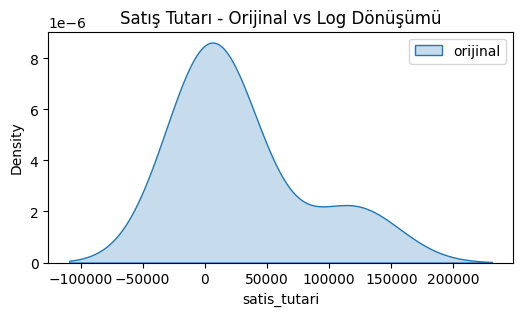

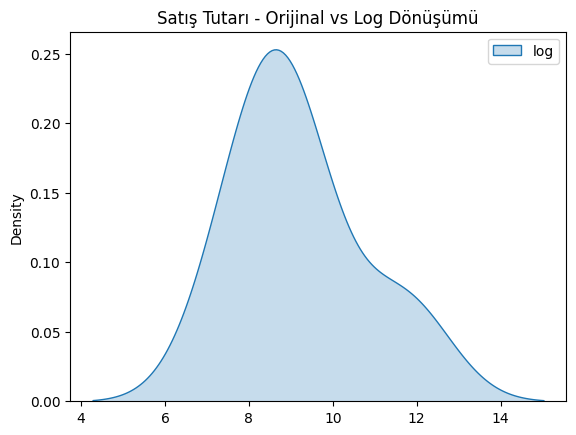

In [ ]:
# dağılım farkları
plt.figure(figsize=(6,3))
sns.kdeplot(df["satis_tutari"],label="orijinal",fill=True)
plt.title("Satış Tutarı - Orijinal vs Log Dönüşümü")
plt.legend()
plt.show()
sns.kdeplot(np.ravel(log["satis_tutari"]),label="log",fill=True)
plt.title("Satış Tutarı - Orijinal vs Log Dönüşümü")
plt.legend()
plt.show()

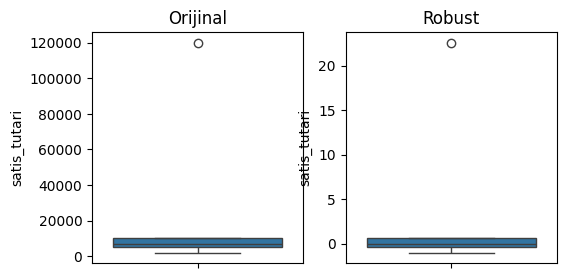

In [ ]:
# outlier etkisini incelemek için boxplot
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
sns.boxplot(df["satis_tutari"])
plt.title("Orijinal")

plt.subplot(1,2,2)
sns.boxplot(robust["satis_tutari"])
plt.title("Robust")
plt.show()

## Durum Çalışması: Diabetes Veri Setinde Normalizasyon
Bu mini projenin amacı:
- Gerçek bir veri seti (diabetes) üzerinden normalizasyonun etkisini gözlemlemek.
- Farklı ölçeklendirme yöntemleriyle verinin nasıl değiştiğini incelemek.
- Normalizasyonun model öncesi aşamada neden kritik olduğunu somut örneklerle anlamak.

### Veri seti: Bu veri seti diyabet hastalığının bazı sağlık ölçümlerini ve kan şekeri seviyelerini içerir.
- sklearn.dataset modülünden indirelim
  - age (20-70)
  - bmi: vücut kitle endeksi (0-50)
  - bp: kan basıncı (60-100)
  - target: kan şekeri seviyesi (25-350)

In [ ]:
# gerekli kütüphaneleri içeri aktar
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# veri yükleme
data = load_diabetes()
X = pd.DataFrame(data.data,columns=data.feature_names)
y = pd.Series(data.target, name="target")
X

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930


In [ ]:
X.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01


In [ ]:
# normalizasyon yöntemlerini uygula
scaler_minmax = MinMaxScaler()
scaler_zscore = StandardScaler()
scaler_robust = RobustScaler()

In [ ]:
X_minmax = pd.DataFrame(scaler_minmax.fit_transform(X),columns=X.columns)
X_zscore = pd.DataFrame(scaler_zscore.fit_transform(X),columns=X.columns)
X_robust = pd.DataFrame(scaler_robust.fit_transform(X),columns=X.columns)
X_log = np.log(X - X.min() + 1)

In [ ]:
# korelasyon değişimini incele
corr_original = X.corr()
corr_minmax = X_minmax.corr()
corr_zscore = X_zscore.corr()
corr_robust = X_robust.corr()
corr_log = X_log.corr()

In [ ]:
corr_original

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
age,1.000000,0.173737,0.185085,0.335428,0.260061,0.219243,-0.075181,0.203841,0.270774,0.301731
sex,0.173737,1.000000,0.088161,0.241010,0.035277,0.142637,-0.379090,0.332115,0.149916,0.208133
bmi,0.185085,0.088161,1.000000,0.395411,0.249777,0.261170,-0.366811,0.413807,0.446157,0.388680
bp,0.335428,0.241010,0.395411,1.000000,0.242464,0.185548,-0.178762,0.257650,0.393480,0.390430
s1,0.260061,0.035277,0.249777,0.242464,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717
s2,0.219243,0.142637,0.261170,0.185548,0.896663,1.000000,-0.196455,0.659817,0.318357,0.290600
s3,-0.075181,-0.379090,-0.366811,-0.178762,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697
s4,0.203841,0.332115,0.413807,0.257650,0.542207,0.659817,-0.738493,1.000000,0.617859,0.417212
s5,0.270774,0.149916,0.446157,0.393480,0.515503,0.318357,-0.398577,0.617859,1.000000,0.464669
s6,0.301731,0.208133,0.388680,0.390430,0.325717,0.290600,-0.273697,0.417212,0.464669,1.000000


In [ ]:
corr_minmax

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
age,1.000000,0.173737,0.185085,0.335428,0.260061,0.219243,-0.075181,0.203841,0.270774,0.301731
sex,0.173737,1.000000,0.088161,0.241010,0.035277,0.142637,-0.379090,0.332115,0.149916,0.208133
bmi,0.185085,0.088161,1.000000,0.395411,0.249777,0.261170,-0.366811,0.413807,0.446157,0.388680
bp,0.335428,0.241010,0.395411,1.000000,0.242464,0.185548,-0.178762,0.257650,0.393480,0.390430
s1,0.260061,0.035277,0.249777,0.242464,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717
s2,0.219243,0.142637,0.261170,0.185548,0.896663,1.000000,-0.196455,0.659817,0.318357,0.290600
s3,-0.075181,-0.379090,-0.366811,-0.178762,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697
s4,0.203841,0.332115,0.413807,0.257650,0.542207,0.659817,-0.738493,1.000000,0.617859,0.417212
s5,0.270774,0.149916,0.446157,0.393480,0.515503,0.318357,-0.398577,0.617859,1.000000,0.464669
s6,0.301731,0.208133,0.388680,0.390430,0.325717,0.290600,-0.273697,0.417212,0.464669,1.000000


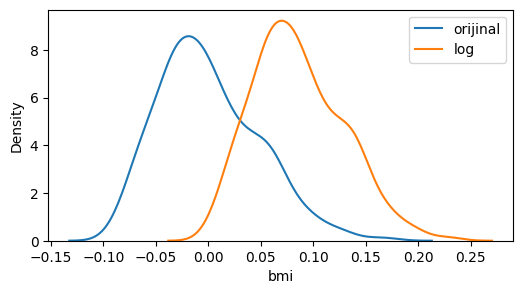

In [ ]:
# bmi sütunu için dağılım farkı
plt.figure(figsize=(6,3))
sns.kdeplot(X["bmi"],label="orijinal")
sns.kdeplot(X_log["bmi"], label="log")
plt.legend()
plt.show()